<a href="https://colab.research.google.com/github/raissabarb/cn/blob/main/Atividade_4_Raissa_Barbosa_Sistemas_Lineares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios — Sistemas lineares e implementação numérica

Aluna: Raissa Barbosa dos Santos

# Parte 1 — Conceitos e resolução manual

## Exercício 1

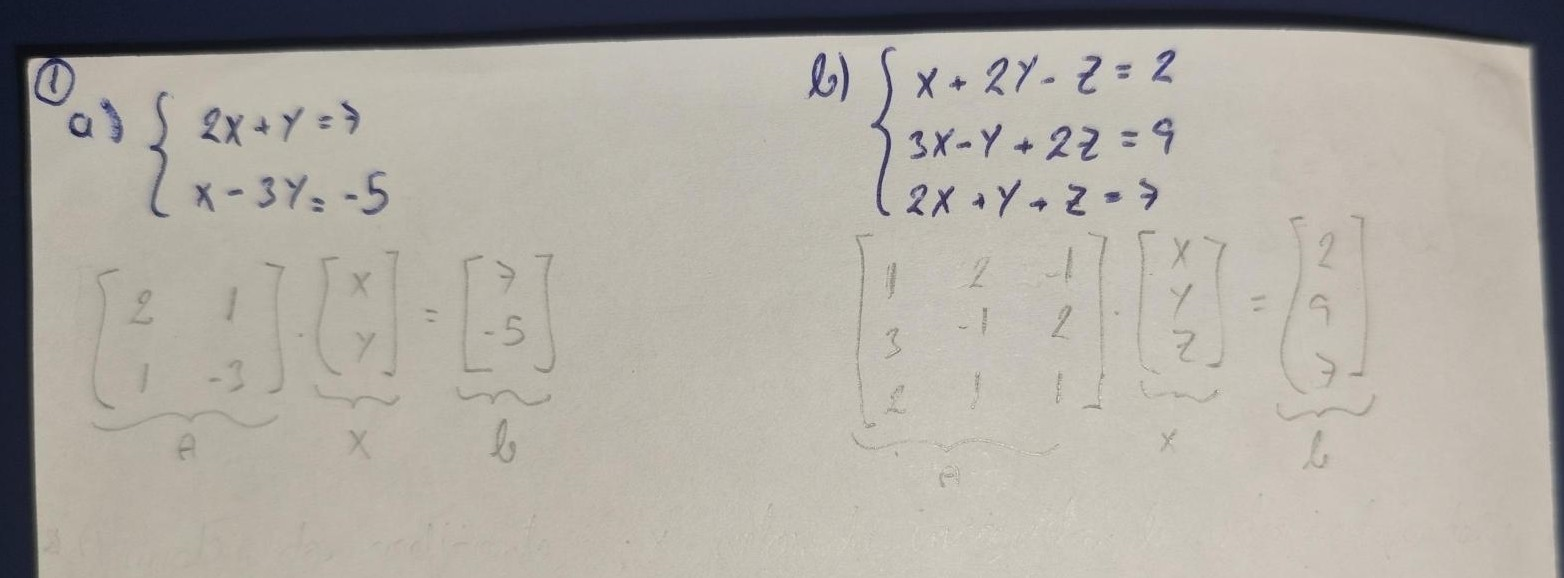

## Exercício 2

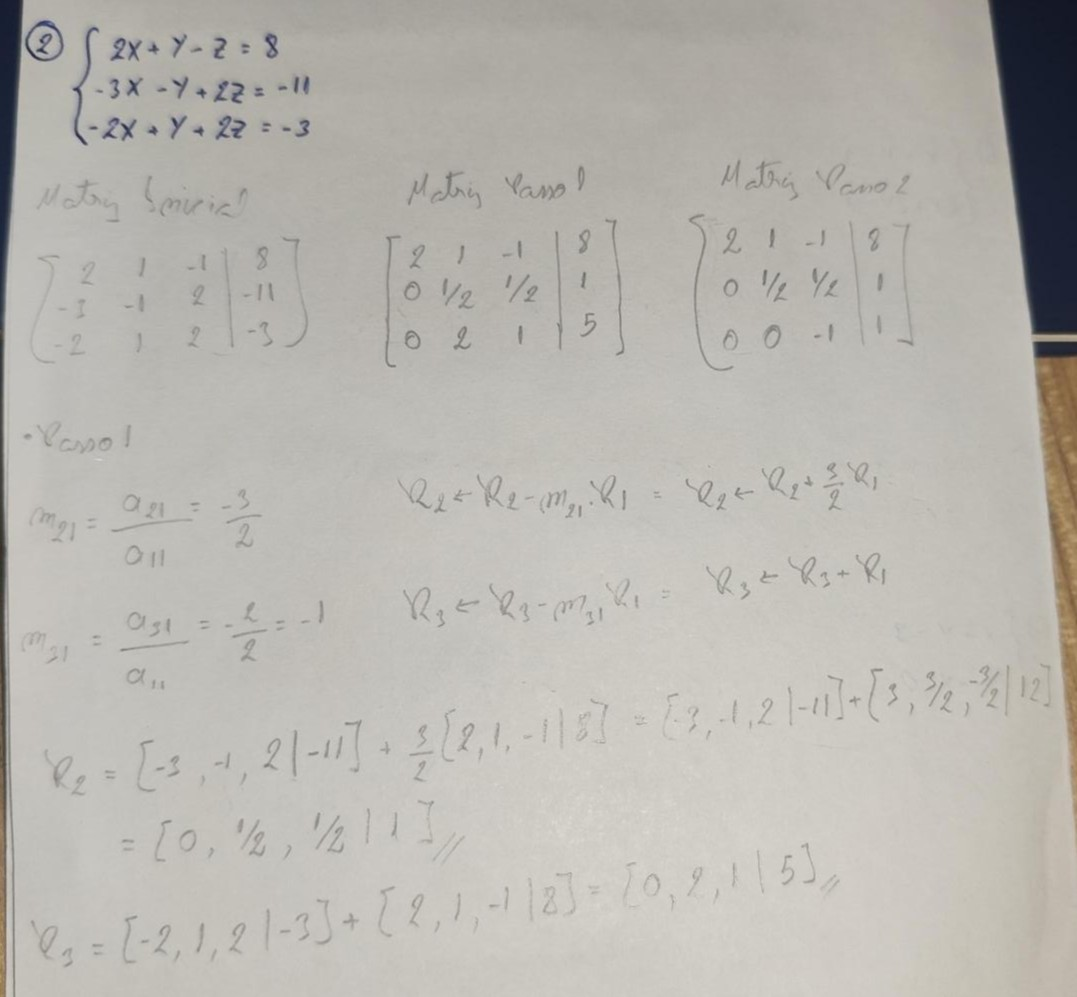

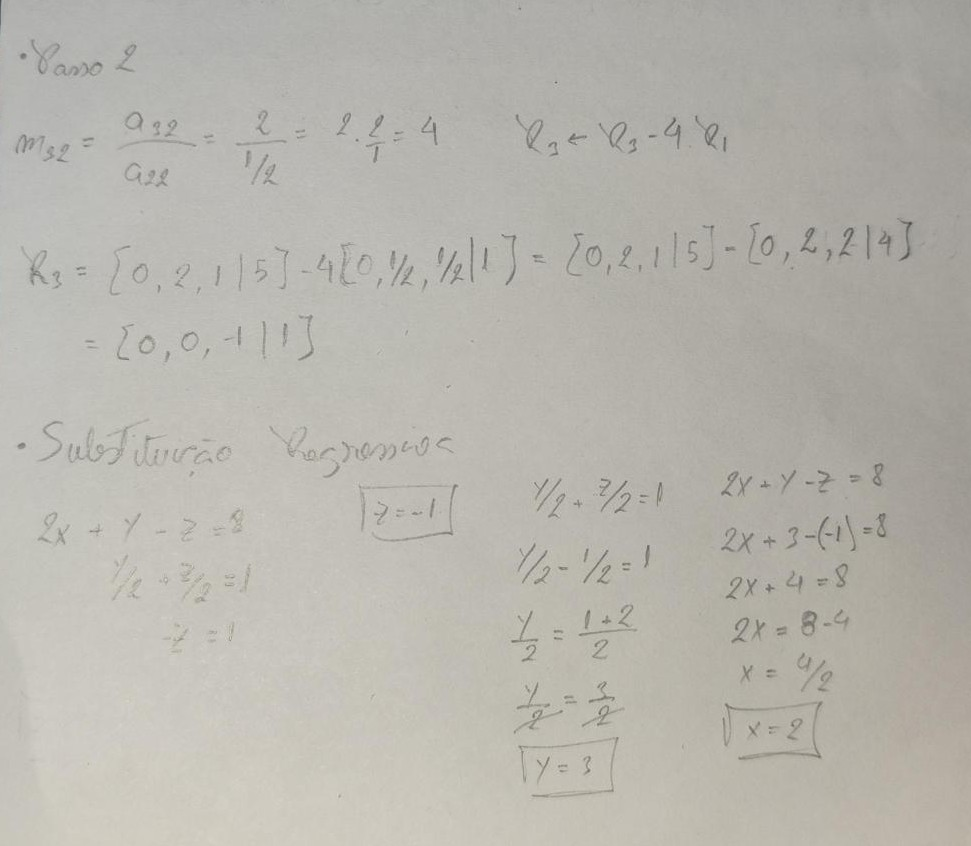

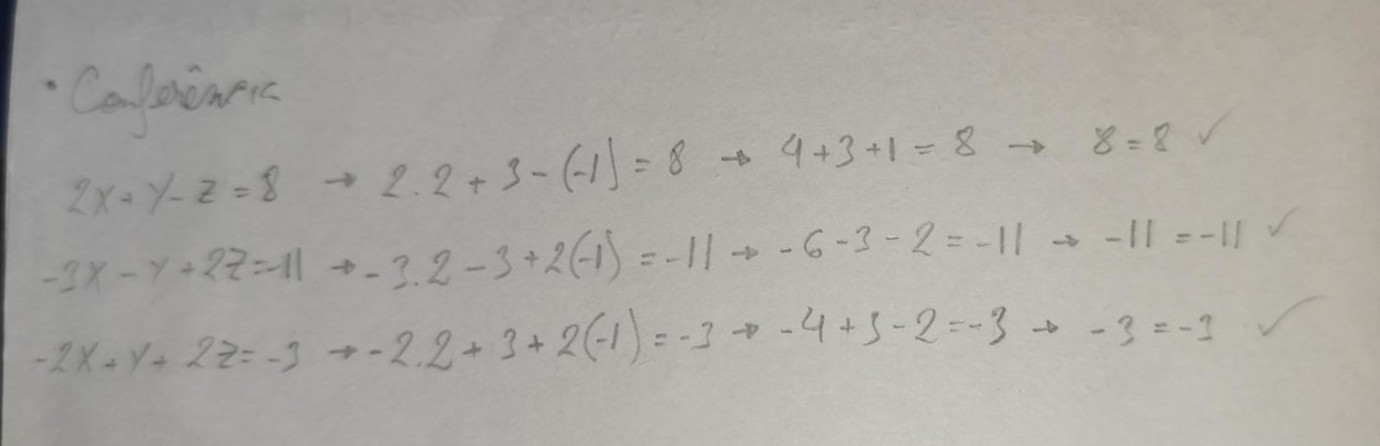

# Parte 2 — Propriedades e interpretação

## Exercício 3 — Número de soluções

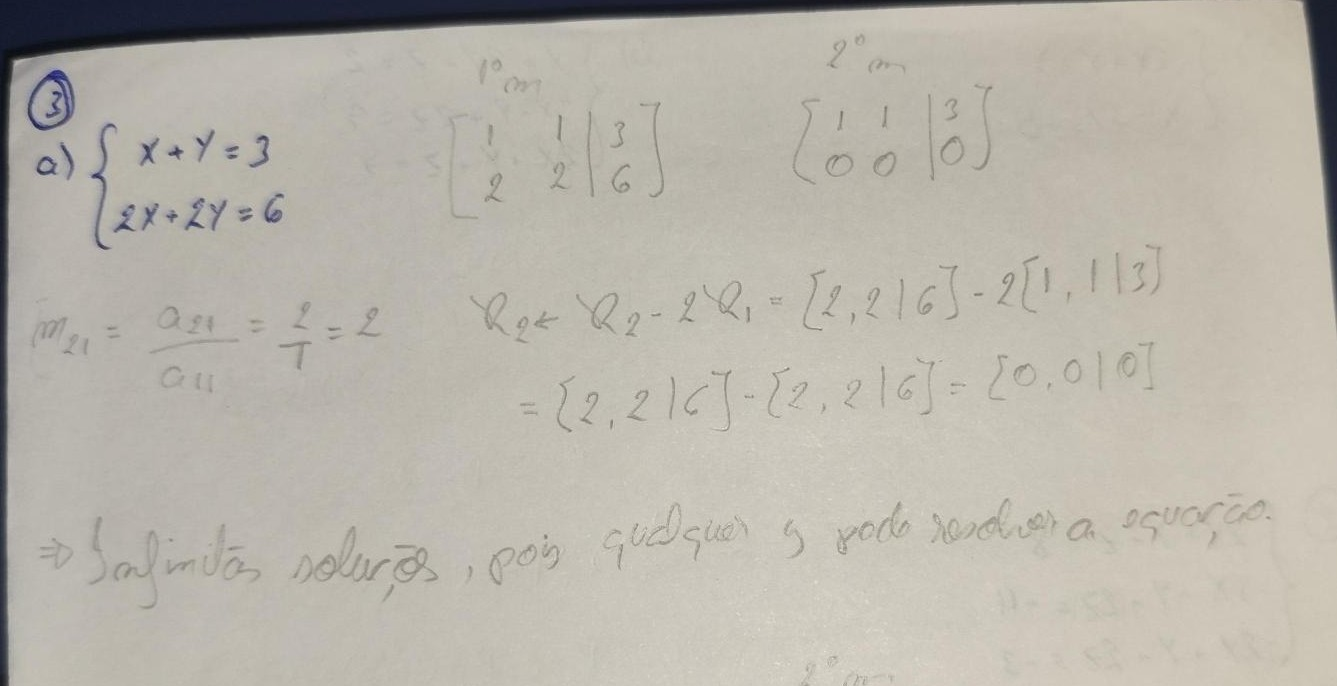

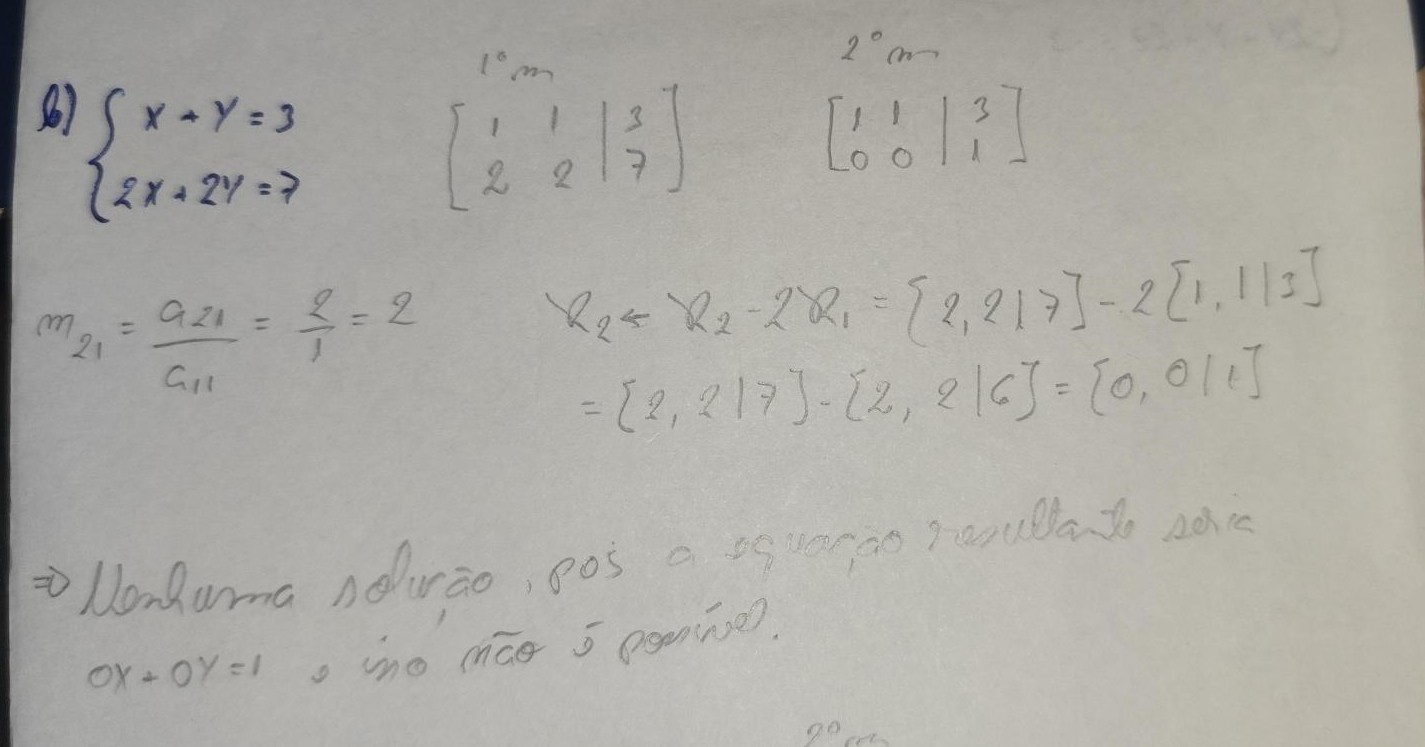

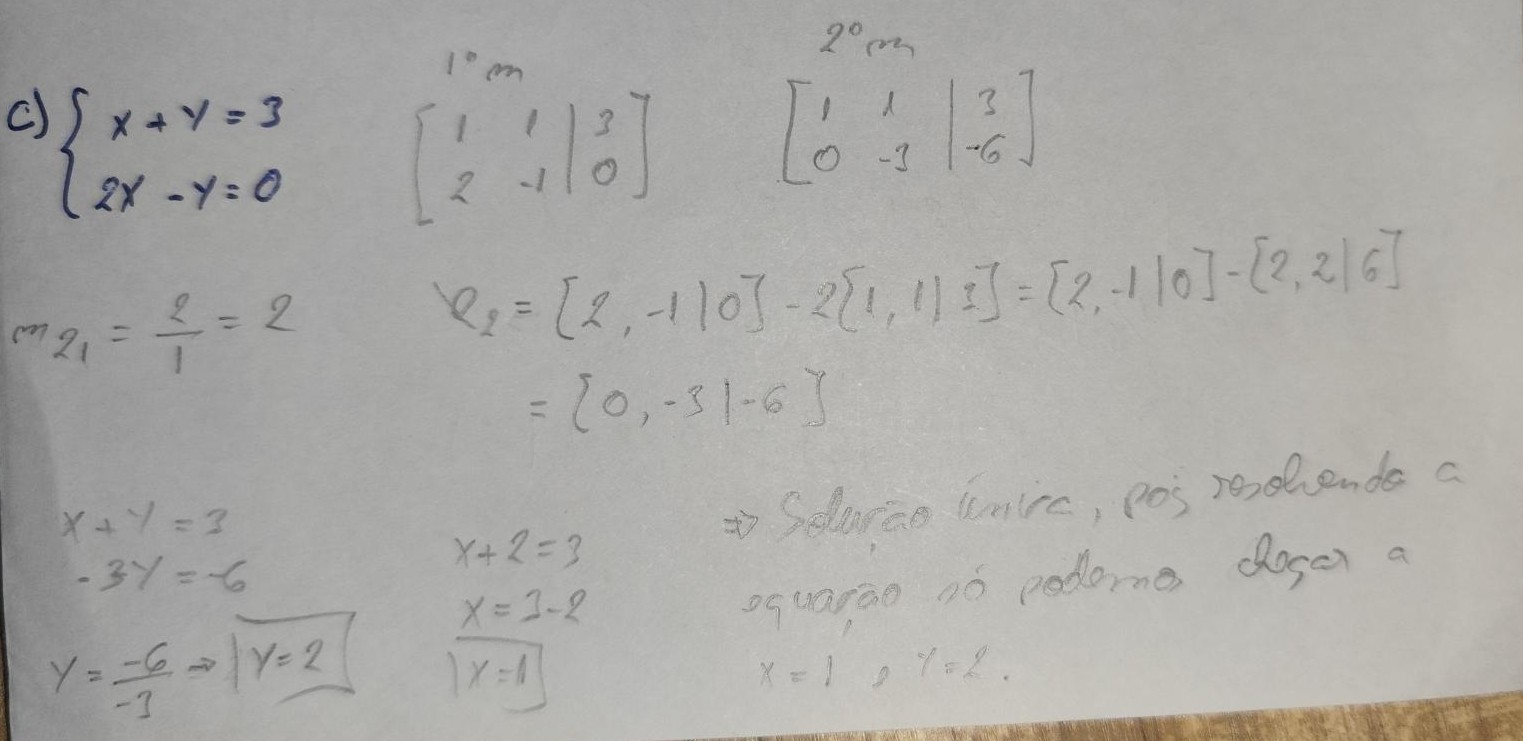

# Parte 3 — Implementação numérica em Python

## Exercício 4 — Eliminação de Gauss sem pivoteamento


In [10]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)

def substituicao_regressiva(U, c):
    '''Resolve Ux=c, onde U é triangular superior.'''
    U = np.asarray(U, dtype=float)
    c = np.asarray(c, dtype=float)
    n = len(c)
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        if abs(U[i,i]) < 1e-14:
            raise np.linalg.LinAlgError("Pivô nulo na substituição regressiva")
        x[i] = (c[i] - U[i,i+1:] @ x[i+1:]) / U[i,i]
    return x

In [11]:
def gauss(A, b, verbose=False, tol=1e-12):

    # Resolve Ax=b por eliminação de Gauss sem pivoteamento. Temos como retorna a solução x e a matriz aumentada triangularizada
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    if A.shape != (n, n):
        raise ValueError("A deve ser quadrada e compatível com b")

    # Matriz aumentada inicial
    M = np.column_stack((A, b))
    if verbose:
        print("Matriz aumentada inicial:\n", M)

    # Eliminações: para cada pivô k, zera os elementos abaixo dele, linha por linha
    for k in range(n - 1):
        if abs(M[k, k]) < tol:
            raise np.linalg.LinAlgError(f"Pivô nulo na etapa {k+1}: seria necessário trocar linhas")
        for i in range(k + 1, n):
            m = M[i, k] / M[k, k]
            M[i, k:] -= m * M[k, k:]   # Ri <- Ri - mik * Rk
            M[i, k] = 0.0
        if verbose:
            print(f"\nApós eliminar a coluna {k+1}:\n", M)

    # Substituição regressiva
    x = substituicao_regressiva(M[:, :-1], M[:, -1])
    return x, M

# Teste com o Exercício 2
A2 = np.array([[ 2.,  1., -1.],
               [-3., -1.,  2.],
               [-2.,  1.,  2.]])
b2 = np.array([8., -11., -3.])

x_gauss, M_tri = gauss(A2, b2, verbose=True)
x_numpy = np.linalg.solve(A2, b2)

# Resultado com numpy.linalg.solve
print("\nSolução com passo a passo:", x_gauss)
print("Solução com numpy.linalg.solve:", x_numpy)

Matriz aumentada inicial:
 [[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]]

Após eliminar a coluna 1:
 [[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   2.   1.   5. ]]

Após eliminar a coluna 2:
 [[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]]

Solução com passo a passo: [ 2.  3. -1.]
Solução com numpy.linalg.solve: [ 2.  3. -1.]


Ambos os métodos resultaram nos mesmos X e Y, confirmando que o passo a passo do código está correto. O resultado ficou correto pois em nenhum momento a diagonal principal da matriz ficou zerada, algo que o pivoteamento evitaria.

# Parte 4 — Aplicação

## Exercício 5

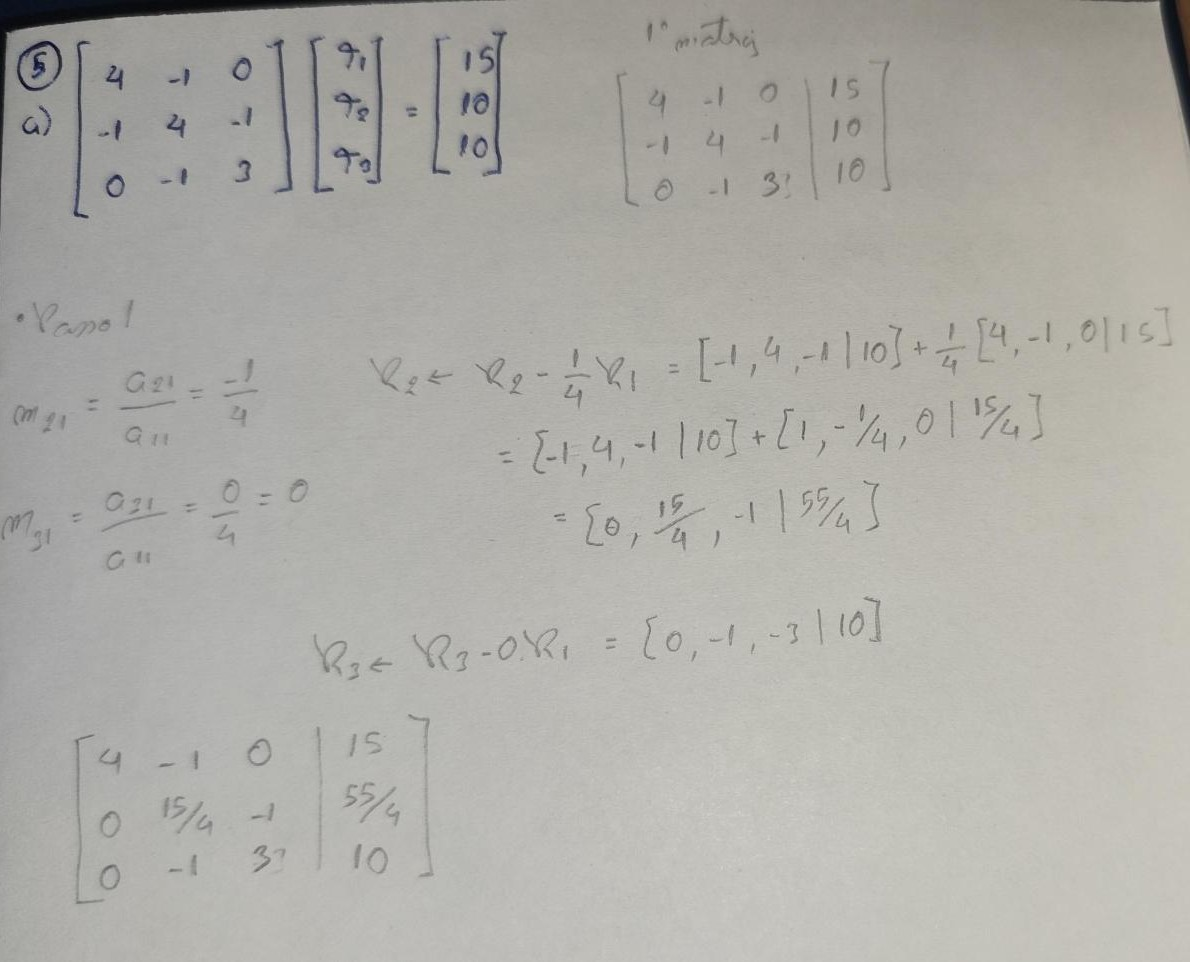

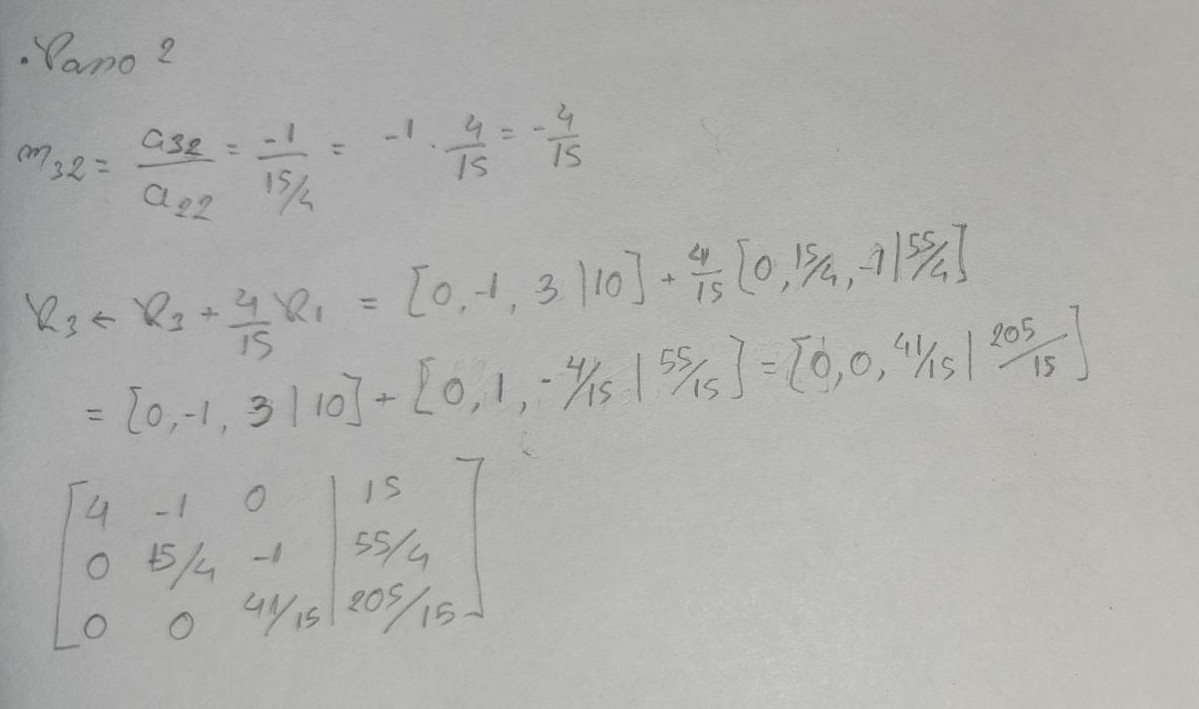

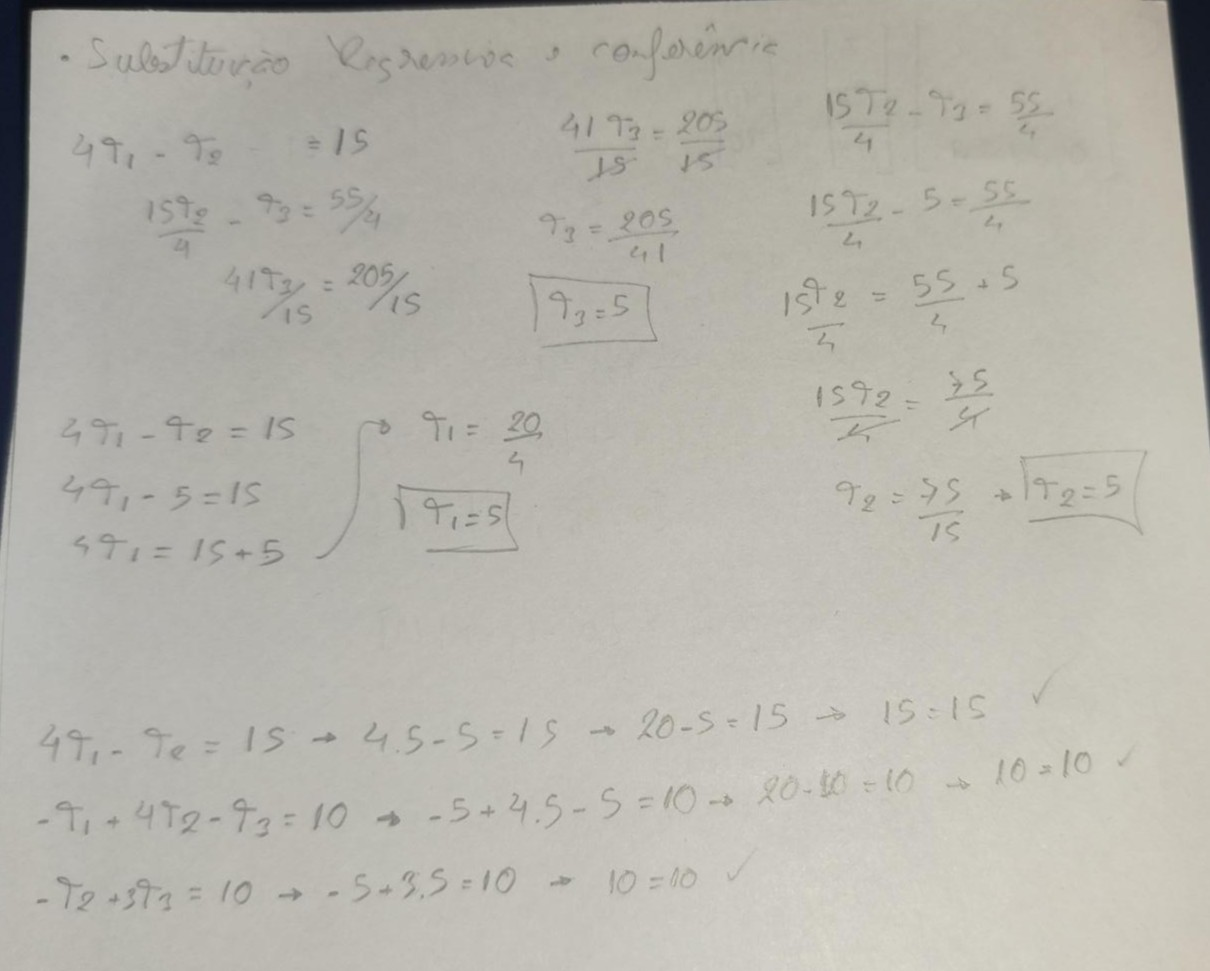

In [14]:
# Modelo de balanço térmico
A5 = np.array([[ 4., -1.,  0.],
               [-1.,  4., -1.],
               [ 0., -1.,  3.]])
b5 = np.array([15., 10., 10.])

T, M5 = gauss(A5, b5, verbose=True)

print("\nTemperaturas T1, T2 e T3 por Gauss:", T)
print("Solução com numpy.linalg.solve:", np.linalg.solve(A5, b5))

Matriz aumentada inicial:
 [[ 4. -1.  0. 15.]
 [-1.  4. -1. 10.]
 [ 0. -1.  3. 10.]]

Após eliminar a coluna 1:
 [[ 4.   -1.    0.   15.  ]
 [ 0.    3.75 -1.   13.75]
 [ 0.   -1.    3.   10.  ]]

Após eliminar a coluna 2:
 [[ 4.       -1.        0.       15.      ]
 [ 0.        3.75     -1.       13.75    ]
 [ 0.        0.        2.733333 13.666667]]

Temperaturas T1, T2 e T3 por Gauss: [5. 5. 5.]
Solução com numpy.linalg.solve: [5. 5. 5.]


Novamente os resultados bateram, confirmando a corretude do código.